# AI-Based Resume Screening and Candidate Shortlisting System
**Machine Learning project** | Dataset: `dataset.csv` (resume, job description, select/reject decision)

**Pipeline:** EDA → leakage check → cleaning (anonymisation) → feature engineering → model comparison → evaluation → explainability → ranked shortlisting → save model

## 1. Setup

In [18]:
import re, warnings, joblib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
DATA_PATH = 'resume_screening_dataset.csv'   # change if your file is elsewhere

## 2. Load data and exploratory analysis

In [19]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
print(df.isna().sum())
df.head(3)

(10000, 10)
Candidate_ID           0
Role                   0
Resume                 0
Job_Description        0
Years_Experience       0
Education_Level        0
Num_Projects           0
Num_Certifications     0
Decision               0
Reason_for_decision    0
dtype: int64


,Candidate_ID,Role,Resume,Job_Description,Years_Experience,Education_Level,Num_Projects,Num_Certifications,Decision,Reason_for_decision
0,C06253,Cloud Engineer,Kavya Smith\nCloud Engineer\nEmail: kavya.smit...,Join us as a Cloud Engineer. Key skills: Amazo...,7,Master's,3,3,select,Matches 6 of 7 required skills; meets the expe...
1,C04685,Full Stack Developer,Ava Nair\nFull Stack Developer\nEmail: ava.nai...,Full Stack Developer opening: we are looking f...,9,Master's,4,1,reject,"Missing required skills: git, rest apis, css."
2,C01732,DevOps Engineer,Daniel Johnson\nCybersecurity Analyst\nEmail: ...,Our growing company needs a DevOps Engineer sk...,1,Master's,4,0,reject,"Missing required skills: aws, monitoring, kube..."


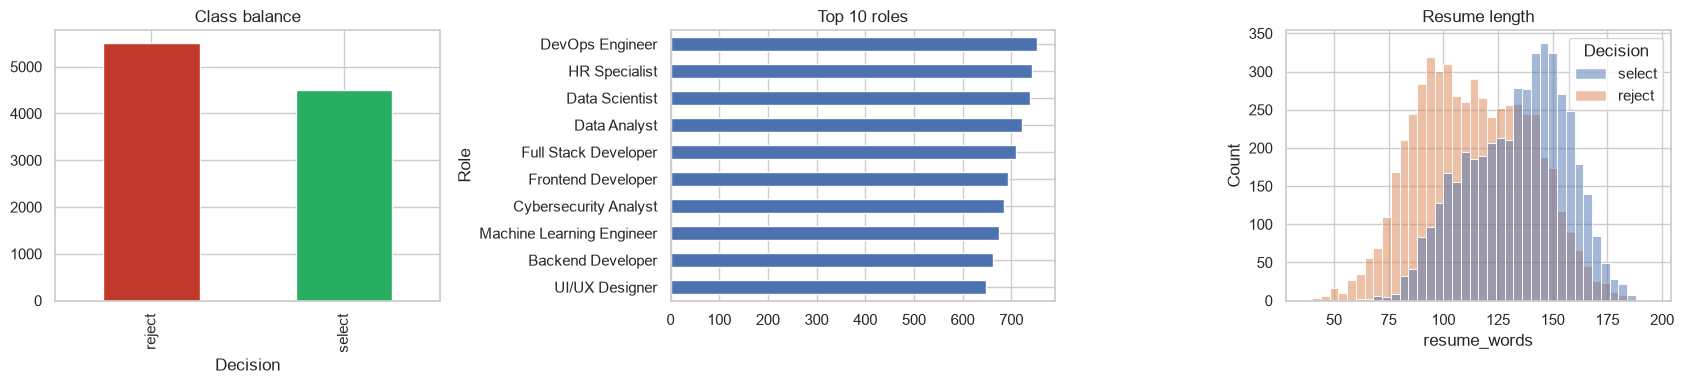

Unique roles: 15 | unique JDs: 1500


In [20]:
df['target'] = (df['Decision'].str.lower() == 'select').astype(int)
df['resume_words'] = df['Resume'].str.split().str.len()
df['jd_words'] = df['Job_Description'].str.split().str.len()

fig, ax = plt.subplots(1, 3, figsize=(17, 4))
df['Decision'].value_counts().plot.bar(ax=ax[0], color=['#c0392b', '#27ae60'], title='Class balance')
df['Role'].value_counts().head(10).plot.barh(ax=ax[1], title='Top 10 roles').invert_yaxis()
sns.histplot(data=df, x='resume_words', hue='Decision', bins=40, ax=ax[2]); ax[2].set_title('Resume length')
plt.tight_layout(); plt.show()
print('Unique roles:', df.Role.nunique(), '| unique JDs:', df.Job_Description.nunique())

## 3. Target-leakage check
`Reason_for_decision` is written *after* the decision, so it should **not** be used as a model feature.
The test below shows why: a model that sees only the reason almost perfectly predicts the label.

In [21]:
a = TfidfVectorizer().fit_transform(df['Reason_for_decision'])
Xa, Xb, ya, yb = train_test_split(a, df['target'], test_size=0.2, stratify=df['target'], random_state=RANDOM_STATE)
print('Accuracy using ONLY Reason_for_decision:', round(LogisticRegression(max_iter=1000).fit(Xa, ya).score(Xb, yb), 3))
print('-> leakage. This column is excluded from all models below (used only for analysis).')

Accuracy using ONLY Reason_for_decision: 1.0
-> leakage. This column is excluded from all models below (used only for analysis).


## 4. Cleaning and anonymisation
Names, emails, phone numbers and links are removed so the model cannot learn from personal identifiers (reduces bias risk).

In [22]:
def clean_resume(text):
    m = re.match(r"Here's a professional resume for ([^:\n]+):", text)
    if m:                                   # format 1: "Here's a professional resume for <name>:"
        name, t = m.group(1).strip(), re.sub(r"^Here's a professional resume for [^:\n]+:\s*", '', text)
    else:                                   # format 2: first line of the resume is the candidate name
        name, _, t = text.partition('\n')
        name = name.strip()
    if name:
        t = t.replace(name, ' ')
    t = re.sub(r'\[([^\]]*)\]\([^)]*\)', ' ', t)           # markdown links (emails/urls)
    t = re.sub(r'\S+@\S+', ' ', t)                            # emails
    t = re.sub(r'(https?://|www\.)\S+|linkedin\.com/\S+|github\.com/\S+', ' ', t)
    t = re.sub(r'\+?\d[\d\-\s().]{8,}\d', ' ', t)             # phones
    t = re.sub(r'[*#_`>]+', ' ', t)                            # markdown symbols
    return re.sub(r'\s+', ' ', t).strip().lower()

df['resume_clean'] = df['Resume'].map(clean_resume)
df['jd_clean'] = df['Job_Description'].str.lower().str.replace(r'\s+', ' ', regex=True)
print(df['resume_clean'].iloc[0][:500])

cloud engineer email: | phone: | summary detail-oriented cloud engineer bringing 7 years of experience in python, azure, linux. skills python, azure, linux, networking, terraform, gcp, security, amazon web services, docker experience cloud engineer, corestack (3 years) - collaborated with cross-functional teams applying networking across 38 projects. - automated recurring tasks using amazon web services, saving about 38 hours per week. - automated recurring tasks using linux, saving about 31 hou


## 5. Feature engineering
Beyond raw text, a screening system should measure **how well a resume matches the job**:
* TF-IDF vectors of resume and job description
* Resume–JD cosine similarity
* Skill overlap (skills in JD that appear in the resume)
* Years of experience, resume length, section counts

In [23]:
SKILLS = ['a/b testing', 'accessibility', 'adobe xd', 'agile', 'airflow', 'ansible', 'api testing', 'aws', 'azure', 'bash', 'brd', 'canva', 'ci/cd', 'cloud security', 'cloudformation', 'computer vision', 'confluence', 'content marketing', 'copywriting', 'crm', 'css', 'cypress', 'data cleaning', 'data visualization', 'data warehousing', 'deep learning', 'design systems', 'docker', 'email marketing', 'employee relations', 'etl', 'excel', 'figma', 'firewalls', 'gcp', 'git', 'google ads', 'google analytics', 'graphql', 'hadoop', 'helm', 'hris', 'html', 'hubspot', 'incident response', 'iso 27001', 'java', 'javascript', 'jenkins', 'jest', 'jira', 'kafka', 'kubernetes', 'labor law', 'linux', 'looker', 'machine learning', 'manual testing', 'microservices', 'mlops', 'mongodb', 'monitoring', 'motion design', 'network security', 'networking', 'next.js', 'nlp', 'node.js', 'onboarding', 'owasp', 'pandas', 'payroll', 'penetration testing', 'performance management', 'performance testing', 'postgresql', 'postman', 'power bi', 'process modeling', 'prometheus', 'prototyping', 'python', 'pytorch', 'r', 'react', 'recruitment', 'redis', 'redux', 'requirements gathering', 'responsive design', 'rest apis', 'risk assessment', 'scala', 'scikit-learn', 'security', 'selenium', 'sem', 'seo', 'serverless', 'siem', 'sketch', 'snowflake', 'social media marketing', 'sourcing', 'spark', 'splunk', 'spring boot', 'sql', 'stakeholder management', 'statistics', 'tableau', 'talent acquisition', 'tensorflow', 'terraform', 'test automation', 'test cases', 'training and development', 'typescript', 'uml', 'usability testing', 'user research', 'webpack', 'wireframing', 'wireshark', 'workday']

SYN = {'ml': 'machine learning', 'sklearn': 'scikit-learn', 'powerbi': 'power bi', 'js': 'javascript', 'nodejs': 'node.js',
       'restful services': 'rest apis', 'k8s': 'kubernetes', 'postgres': 'postgresql', 'amazon web services': 'aws',
       'search engine optimization': 'seo', 'ga4': 'google analytics', 'hr information systems': 'hris', 'neural networks': 'deep learning',
       'automation testing': 'test automation', 'siem tools': 'siem', 'etl pipelines': 'etl', 'ci/cd pipelines': 'ci/cd',
       'natural language processing': 'nlp'}

def normalise(text):
    for k, v in SYN.items():
        text = re.sub(r'(?<![a-z0-9])' + re.escape(k) + r'(?![a-z0-9])', v, text)
    return text

def skills_in(text):
    text = normalise(text)
    return {s for s in SKILLS if re.search(r'(?<![a-z])' + re.escape(s) + r'(?![a-z])', text)}

def years_exp(text):
    m = re.findall(r'(\d+)\+?\s*years', text)
    return max(map(int, m)) if m else 0

def engineered(frame, vec):
    R, J = vec.transform(frame['resume_clean']), vec.transform(frame['jd_clean'])
    cos = np.asarray(R.multiply(J).sum(1)).ravel()
    rs, js = frame['resume_clean'].map(skills_in), frame['jd_clean'].map(skills_in)
    overlap = np.array([len(r & j) / max(len(j), 1) for r, j in zip(rs, js)])
    out = pd.DataFrame({
        'cosine_sim': cos,
        'skill_overlap': overlap,
        'n_resume_skills': rs.map(len).values,
        'n_jd_skills': js.map(len).values,
        'years_exp': frame['resume_clean'].map(years_exp).values,
        'resume_len': frame['resume_clean'].str.split().str.len().values,
        'jd_len': frame['jd_clean'].str.split().str.len().values,
        'role_in_resume': [int(r.lower() in t) for r, t in zip(frame['Role'], frame['resume_clean'])],
    })
    return out

## 6. Train / test split

In [24]:
train_idx, test_idx = train_test_split(df.index, test_size=0.2, stratify=df['target'], random_state=RANDOM_STATE)
train, test = df.loc[train_idx], df.loc[test_idx]
y_train, y_test = train['target'].values, test['target'].values

# vectorizers are fit on TRAIN only (no leakage)
tfidf_shared = TfidfVectorizer(sublinear_tf=True, stop_words='english', min_df=2).fit(pd.concat([train.resume_clean, train.jd_clean]))
tfidf_res = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=60000, sublinear_tf=True).fit(train.resume_clean)
tfidf_jd = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=20000, sublinear_tf=True).fit(train.jd_clean)

F_train, F_test = engineered(train, tfidf_shared), engineered(test, tfidf_shared)
print(F_train.groupby(y_train).mean().round(3).T)

                       0        1
cosine_sim         0.248    0.388
skill_overlap      0.372    0.743
n_resume_skills    6.957    9.560
n_jd_skills        7.537    7.565
years_exp          3.911    5.442
resume_len       108.242  128.023
jd_len            36.133   36.183
role_in_resume     0.667    0.995


## 7. Model comparison

In [25]:
def text_matrix(frame, feats):
    return hstack([tfidf_res.transform(frame.resume_clean), tfidf_jd.transform(frame.jd_clean)]).tocsr()

Xt_train, Xt_test = text_matrix(train, F_train), text_matrix(test, F_test)
scale = F_train.std().replace(0, 1)
Xc_train = hstack([Xt_train, csr_matrix((F_train / scale).values)]).tocsr()
Xc_test = hstack([Xt_test, csr_matrix((F_test / scale).values)]).tocsr()

models = {
 'LogReg (TF-IDF text)':            (LogisticRegression(max_iter=3000, C=3), Xt_train, Xt_test),
 'LogReg (text + match features)':  (LogisticRegression(max_iter=3000, C=3), Xc_train, Xc_test),
 'Linear SVM (text + match)':       (LinearSVC(C=0.3), Xc_train, Xc_test),
 'Complement NB (text)':            (ComplementNB(alpha=0.5), Xt_train, Xt_test),
 'Random Forest (match features)':  (RandomForestClassifier(400, min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE), F_train.values, F_test.values),
 'HistGradBoost (match features)':  (HistGradientBoostingClassifier(max_depth=4, learning_rate=0.05, random_state=RANDOM_STATE), F_train.values, F_test.values),
}

rows, fitted = [], {}
for name, (m, Xtr, Xte) in models.items():
    m.fit(Xtr, y_train)
    pred = m.predict(Xte)
    score = m.predict_proba(Xte)[:, 1] if hasattr(m, 'predict_proba') else m.decision_function(Xte)
    rows.append({'Model': name, 'Accuracy': accuracy_score(y_test, pred), 'Precision': precision_score(y_test, pred),
                 'Recall': recall_score(y_test, pred), 'F1': f1_score(y_test, pred), 'ROC-AUC': roc_auc_score(y_test, score)})
    fitted[name] = (m, Xte, score)

results = pd.DataFrame(rows).set_index('Model').round(3).sort_values('ROC-AUC', ascending=False)
results

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
LogReg (text + match features),0.856,0.833,0.850,0.842,0.936
HistGradBoost (match features),0.859,0.839,0.850,0.844,0.936
Linear SVM (text + match),0.856,0.835,0.847,0.841,0.935
Random Forest (match features),0.857,0.842,0.840,0.841,0.934
LogReg (TF-IDF text),0.690,0.662,0.639,0.650,0.758
Complement NB (text),0.602,0.560,0.533,0.546,0.644


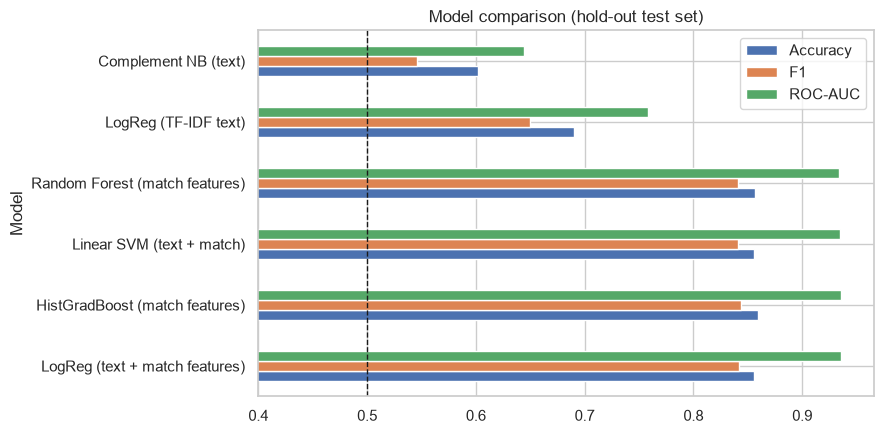

In [26]:
results[['Accuracy', 'F1', 'ROC-AUC']].plot.barh(figsize=(9, 4.5), title='Model comparison (hold-out test set)')
plt.axvline(0.5, color='k', ls='--', lw=1); plt.xlim(0.4, max(0.7, results.max().max() + 0.03)); plt.tight_layout(); plt.show()

### Cross-validation of the best candidates (checks the result is stable)

In [27]:
skf = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
y_all = df['target'].values
X_all_text = hstack([tfidf_res.transform(df.resume_clean), tfidf_jd.transform(df.jd_clean)]).tocsr()
F_all = engineered(df, tfidf_shared)
for name, m, X in [('LogReg text', LogisticRegression(max_iter=3000, C=3), X_all_text),
                   ('HistGB match feats', HistGradientBoostingClassifier(max_depth=4, learning_rate=0.05, random_state=RANDOM_STATE), F_all.values)]:
    s = cross_val_score(m, X, y_all, cv=skf, scoring='roc_auc', n_jobs=-1)
    print(f'{name}: ROC-AUC {s.mean():.3f} ± {s.std():.3f}')

LogReg text: ROC-AUC 0.756 ± 0.011
HistGB match feats: ROC-AUC 0.936 ± 0.005


### Optional: semantic embeddings (run locally; needs internet to download the model)
Sentence embeddings capture meaning ("built ML pipelines" ≈ "machine learning experience") better than keyword TF-IDF.

In [28]:
try:
    from sentence_transformers import SentenceTransformer
    st = SentenceTransformer('all-MiniLM-L6-v2')
    E_res = st.encode(df.resume_clean.tolist(), batch_size=64, show_progress_bar=True)
    E_jd = st.encode(df.jd_clean.tolist(), batch_size=64, show_progress_bar=True)
    emb_cos = (E_res * E_jd).sum(1) / (np.linalg.norm(E_res, axis=1) * np.linalg.norm(E_jd, axis=1))
    X_emb = np.hstack([E_res, E_jd, (E_res * E_jd), emb_cos[:, None], F_all.values])
    s = cross_val_score(LogisticRegression(max_iter=3000), X_emb, y_all, cv=skf, scoring='roc_auc', n_jobs=-1)
    print(f'Embeddings + LogReg: ROC-AUC {s.mean():.3f} ± {s.std():.3f}')
except ImportError:
    print('sentence-transformers not installed -> pip install sentence-transformers (skipping this optional step)')

sentence-transformers not installed -> pip install sentence-transformers (skipping this optional step)


## 8. Detailed evaluation of the best model

Best model: LogReg (text + match features)
              precision    recall  f1-score   support

      reject       0.88      0.86      0.87      1100
      select       0.83      0.85      0.84       900

    accuracy                           0.86      2000
   macro avg       0.85      0.86      0.85      2000
weighted avg       0.86      0.86      0.86      2000



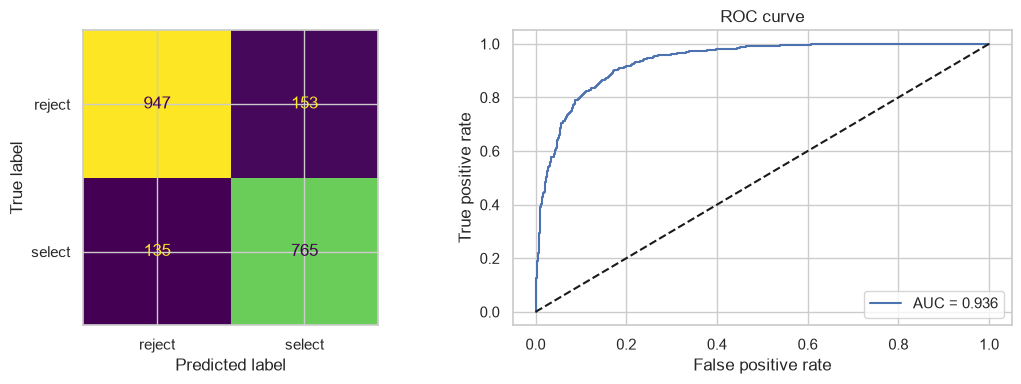

In [29]:
best_name = results.index[0]
best, Xte_best, best_score = fitted[best_name]
best_pred = best.predict(Xte_best)
print('Best model:', best_name)
print(classification_report(y_test, best_pred, target_names=['reject', 'select']))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, best_pred), display_labels=['reject', 'select']).plot(ax=ax[0], colorbar=False)
fpr, tpr, _ = roc_curve(y_test, best_score)
ax[1].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, best_score):.3f}'); ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set(xlabel='False positive rate', ylabel='True positive rate', title='ROC curve'); ax[1].legend()
plt.tight_layout(); plt.show()

In [30]:
# performance per role (are some roles screened worse than others?)
tmp = test.assign(pred=best_pred)
per_role = tmp.groupby('Role').apply(lambda g: pd.Series({'n': len(g), 'accuracy': (g.pred == g.target).mean()}))
per_role[per_role.n >= 20].sort_values('accuracy').round(3).head(10)

,n,accuracy
Role,,
Cloud Engineer,134.0,0.813
Machine Learning Engineer,138.0,0.826
Data Scientist,134.0,0.836
QA Engineer,117.0,0.838
UI/UX Designer,127.0,0.843
DevOps Engineer,143.0,0.853
Cybersecurity Analyst,143.0,0.853
Business Analyst,122.0,0.861
HR Specialist,133.0,0.865


## 9. Explainability — why was a candidate selected?

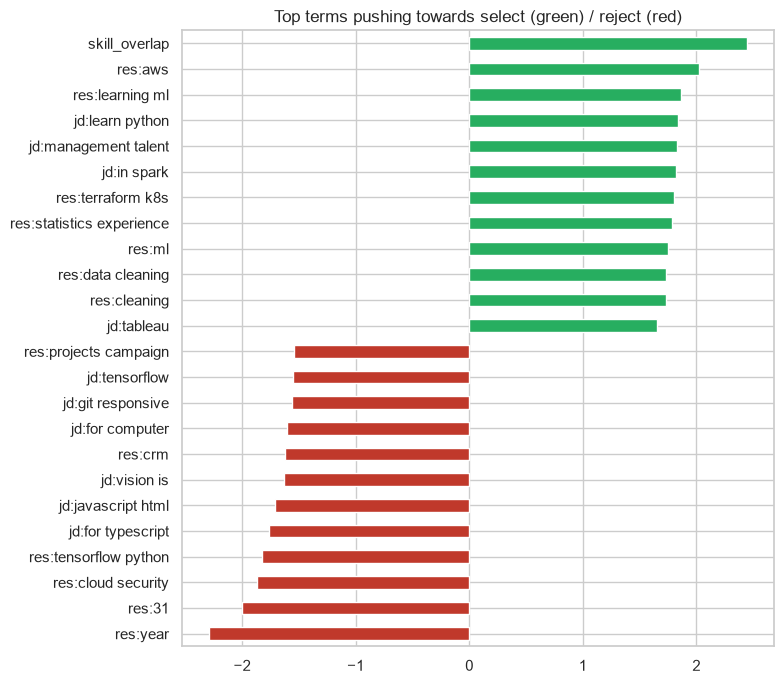

In [31]:
lr_name = 'LogReg (text + match features)'
lr = fitted[lr_name][0]
names = (['res:' + t for t in tfidf_res.get_feature_names_out()] + ['jd:' + t for t in tfidf_jd.get_feature_names_out()]
         + list(F_train.columns))
coef = pd.Series(lr.coef_[0], index=names)
top = pd.concat([coef.nlargest(12), coef.nsmallest(12)]).sort_values()
top.plot.barh(figsize=(8, 7), color=['#c0392b' if v < 0 else '#27ae60' for v in top], title='Top terms pushing towards select (green) / reject (red)')
plt.tight_layout(); plt.show()

## 10. Candidate shortlisting
Instead of a plain select/reject label, the system **ranks** candidates for a job description by predicted probability and returns the top *N*.

In [32]:
final_model = LogisticRegression(max_iter=3000, C=3)
final_model.fit(Xc_train, y_train)

def featurize(resumes, jd, role=''):
    frame = pd.DataFrame({'Role': role, 'resume_clean': [clean_resume(r) for r in resumes], 'jd_clean': jd.lower()})
    F = engineered(frame, tfidf_shared)
    X = hstack([tfidf_res.transform(frame.resume_clean), tfidf_jd.transform(frame.jd_clean), csr_matrix((F / scale).values)]).tocsr()
    return X, F

def shortlist(resumes, job_description, role='', top_n=5, ids=None):
    X, F = featurize(resumes, job_description, role)
    out = pd.DataFrame({'candidate': ids if ids is not None else range(len(resumes)),
                        'score': final_model.predict_proba(X)[:, 1],
                        'skill_overlap': F['skill_overlap'].round(2).values,
                        'cosine_sim': F['cosine_sim'].round(3).values})
    out['rank'] = out['score'].rank(ascending=False, method='first').astype(int)
    return out.sort_values('rank').head(top_n).reset_index(drop=True)

# demo: pick one job description from the test set and rank all test resumes that were screened for that role
role = test['Role'].value_counts().index[0]
pool = test[test.Role == role]
jd_demo = pool['Job_Description'].iloc[0]
print('Role:', role, '| candidates in pool:', len(pool))
shortlist(pool['Resume'].tolist(), jd_demo, role, top_n=5, ids=pool.index.tolist())

Role: Full Stack Developer | candidates in pool: 175


,candidate,score,skill_overlap,cosine_sim,rank
0,9843,0.998388,1.0,0.435,1
1,9890,0.994609,1.0,0.411,2
2,1565,0.993600,1.0,0.304,3
3,5312,0.991708,1.0,0.471,4
4,8720,0.990430,1.0,0.250,5


In [33]:
# ranking quality: of the top-k ranked in each role, how many were truly 'select'?  (compare with random = base rate)
def precision_at_k(k=10):
    res = []
    for r, g in test.groupby('Role'):
        if len(g) < 2 * k: continue
        s = final_model.predict_proba(hstack([tfidf_res.transform(g.resume_clean), tfidf_jd.transform(g.jd_clean),
                                              csr_matrix((engineered(g, tfidf_shared) / scale).values)]).tocsr())[:, 1]
        res.append(g.assign(s=s).nlargest(k, 's')['target'].mean())
    return np.mean(res) if res else float('nan')
print(f'Precision@10 per role (avg): {precision_at_k(10):.3f}   vs random baseline: {test.target.mean():.3f}')

Precision@10 per role (avg): 0.973   vs random baseline: 0.450


## 11. Save the trained pipeline

In [34]:
joblib.dump({'model': final_model, 'tfidf_shared': tfidf_shared, 'tfidf_res': tfidf_res, 'tfidf_jd': tfidf_jd, 'scale': scale},
            'resume_screening_model.joblib')
print('saved resume_screening_model.joblib')

saved resume_screening_model.joblib


## 12. Conclusions and limitations
* **Best models reach about 0.86 accuracy and 0.94 ROC-AUC** (5-fold CV for gradient boosting on match features: 0.936 ± 0.005). Ranking works well: Precision@10 per role is about 0.97 against a 0.45 random baseline.
* **Match features matter.** TF-IDF text alone reaches only about 0.69 accuracy, while adding resume–JD cosine similarity, skill overlap, years of experience and role fit lifts it to about 0.86. Screening is a *matching* problem, not just a text-classification problem.
* **The dataset is synthetic.** Labels come from a hidden weighted score (skills, experience, education, projects, certifications, role fit) plus noise, so these numbers are *not* a claim about real-world hiring accuracy.
* **`Reason_for_decision` leaks the label** (100% accuracy alone), so it is excluded from modelling and used only for explanations.
* **Fairness.** Names, contact details and links are stripped before modelling. A real deployment would also need bias audits, and a human should make the final hiring decision.
* **Future work:** sentence-embedding or fine-tuned transformer matching, PDF resume parsing (pdfplumber), a Streamlit recruiter app, and validation on real labelled data.